# Support Triage Workflow

Notebook version of the learner support triage graph.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd() / "src"))

from dotenv import load_dotenv
from enums import StatusEnum, CategoryEnum, PriorityEnum, RouteEnum
import json
from langgraph.graph import StateGraph, START, END
from typing import Literal, TypedDict
from IPython.display import Image, display

load_dotenv()


True

In [2]:
class AgentState(TypedDict):
    learner_name: str
    email: str
    category: Literal["technical", "billing", "course_content", "general"]
    message: str
    days_until_deadline: int
    is_paid_student: bool
    priority_score: int
    priority: Literal["low", "high", "normal", "urgent"]
    route: Literal[
        "urgent", "technical", "billing", "learning_support", "general"
    ]
    assigned_team: str
    status: Literal["received", "escalated", "triaged"]
    response: str
    audit_log: list[str]


In [3]:
def calculate_priority(state: AgentState) -> tuple[int, str]:
    score = 0
    message = state["message"].lower()
    category = state["category"]
    days = state["days_until_deadline"]
    emergency_keywords = ["blocked", "cannot submit", "charged twice", "deadline"]

    # Rule 1: deadline pressure gets urgent treatment.
    if days <= 1:
        score += 50

    # Rule 2: technical issues are higher priority than general requests.
    if category == CategoryEnum.TECHNICAL:
        score += 25
    elif category == CategoryEnum.BILLING:
        score += 20
    elif category == CategoryEnum.GENERAL:
        score += 5

    # Rule 3: emergency keywords raise priority.
    if any(word in message for word in emergency_keywords):
        score += 30

    # Optional business rule: paid learners get a small boost.
    if state["is_paid_student"]:
        score += 10

    if score >= 70:
        priority = PriorityEnum.URGENT.value
    elif 35 <= score < 70:
        priority = PriorityEnum.HIGH.value
    elif 16 <= score < 35:
        priority = PriorityEnum.NORMAL.value
    else:
        priority = PriorityEnum.LOW.value

    return score, priority


def route_request(
    state: AgentState,
) -> Literal["urgent", "technical", "billing", "learning_support", "general"]:
    category = state["category"]
    priority = state["priority"]

    if priority == PriorityEnum.URGENT:
        return RouteEnum.URGENT.value
    if category == CategoryEnum.TECHNICAL:
        return RouteEnum.TECHNICAL.value
    if category == CategoryEnum.BILLING:
        return RouteEnum.BILLING.value
    if category == CategoryEnum.COURSE:
        return RouteEnum.LEARNING.value

    return RouteEnum.GENERAL.value


In [4]:
def intake_node(state: AgentState) -> dict:
    name = state["learner_name"]
    email = state["email"]
    category = state["category"]
    audit = state.get("audit_log", [])
    entry = f"Received support request from {name} ({email}) in category '{category}'."

    return {
        "status": StatusEnum.RECEIVED.value,
        "audit_log": audit + [entry],
    }


# Scoring rules:
# 1. If days_until_deadline <= 1, add a large urgency boost.
# 2. Technical issues score higher than general requests.
# 3. Emergency keywords in the learner's message increase priority.
# 4. Paid learners can receive a small additional boost.
def calculate_priority_node(state: AgentState) -> dict:
    score, priority = calculate_priority(state)
    audit = state.get("audit_log", [])
    entry = f"Priority calculated: {priority}, ({score})"

    return {
        "priority_score": score,
        "priority": priority,
        "status": StatusEnum.RECEIVED.value,
        "audit_log": audit + [entry],
    }


def route_request_node(state: AgentState) -> dict:
    route = route_request(state)
    audit = state.get("audit_log", [])

    return {
        "route": route,
        "audit_log": audit + [f"Request routed to {route}."],
    }


def urgent_node(state: AgentState) -> dict:
    audit_log = state.get("audit_log", [])
    return {
        "route": RouteEnum.URGENT.value,
        "assigned_team": "on_call_instructor",
        "status": StatusEnum.ESCALATED.value,
        "response": (
            "Your request has been marked urgent and escalated for immediate review. "
            "A specialist will contact you as soon as possible."
        ),
        "audit_log": audit_log + ["Routed to urgent queue and escalated to on_call_instructor."],
    }


def technical_node(state: AgentState) -> dict:
    audit_log = state.get("audit_log", [])
    return {
        "route": RouteEnum.TECHNICAL.value,
        "assigned_team": "technical_support",
        "status": StatusEnum.RECEIVED.value,
        "response": (
            "Your issue has been assigned to technical support. "
            "We are reviewing the platform problem and will follow up shortly."
        ),
        "audit_log": audit_log + ["Routed to technical queue and assigned to technical_support."],
    }


def billing_node(state: AgentState) -> dict:
    audit_log = state.get("audit_log", [])
    return {
        "route": RouteEnum.BILLING.value,
        "assigned_team": "billing_operations",
        "status": StatusEnum.RECEIVED.value,
        "response": (
            "Your billing request has been sent to our billing team. "
            "We will review the charge or payment issue and get back to you."
        ),
        "audit_log": audit_log + ["Routed to billing queue and assigned to billing_operations."],
    }


def learning_support_node(state: AgentState) -> dict:
    audit_log = state.get("audit_log", [])
    return {
        "route": RouteEnum.LEARNING.value,
        "assigned_team": "learning_success",
        "status": StatusEnum.RECEIVED.value,
        "response": (
            "Your course content concern has been shared with the learning support team. "
            "We will help clarify the material or next learning step."
        ),
        "audit_log": audit_log + ["Routed to learning_support queue and assigned to learning_success."],
    }


def general_node(state: AgentState) -> dict:
    audit_log = state.get("audit_log", [])
    return {
        "route": RouteEnum.GENERAL.value,
        "assigned_team": "general_support",
        "status": StatusEnum.RECEIVED.value,
        "response": (
            "Your request has been received by general support. "
            "We will review it and direct it to the right team if needed."
        ),
        "audit_log": audit_log + ["Routed to general queue and assigned to general_support."],
    }


def summary_node(state: AgentState) -> dict:
    audit_log = state.get("audit_log", [])
    priority = state["priority"]
    assigned_team = state["assigned_team"]
    current_response = state["response"]

    if priority == PriorityEnum.URGENT:
        final_status = StatusEnum.ESCALATED
    else:
        final_status = StatusEnum.TRIAGED

    final_response = (
        f"{current_response} Priority: {priority}. Assigned team: {assigned_team}."
    )

    return {
        "status": final_status.value,
        "response": final_response,
        "audit_log": audit_log + [
            f"Triage summary '{final_status.value}' treated as '{priority}', assigned to '{assigned_team}' team."
        ],
    }


In [5]:
graph = StateGraph(AgentState)

graph.add_node("intake_node", intake_node)
graph.add_node("calculate_priority_node", calculate_priority_node)
graph.add_node("route_request_node", route_request_node)
graph.add_node("urgent_node", urgent_node)
graph.add_node("technical_node", technical_node)
graph.add_node("billing_node", billing_node)
graph.add_node("learning_support_node", learning_support_node)
graph.add_node("general_node", general_node)
graph.add_node("summary_node", summary_node)

graph.add_edge(START, "intake_node")
graph.add_edge("intake_node", "calculate_priority_node")
graph.add_edge("calculate_priority_node", "route_request_node")
graph.add_conditional_edges(
    "route_request_node",
    route_request,
    {
        "urgent": "urgent_node",
        "technical": "technical_node",
        "billing": "billing_node",
        "learning_support": "learning_support_node",
        "general": "general_node",
    },
)
graph.add_edge("urgent_node", "summary_node")
graph.add_edge("technical_node", "summary_node")
graph.add_edge("billing_node", "summary_node")
graph.add_edge("learning_support_node", "summary_node")
graph.add_edge("general_node", "summary_node")
graph.add_edge("summary_node", END)

workflow = graph.compile()


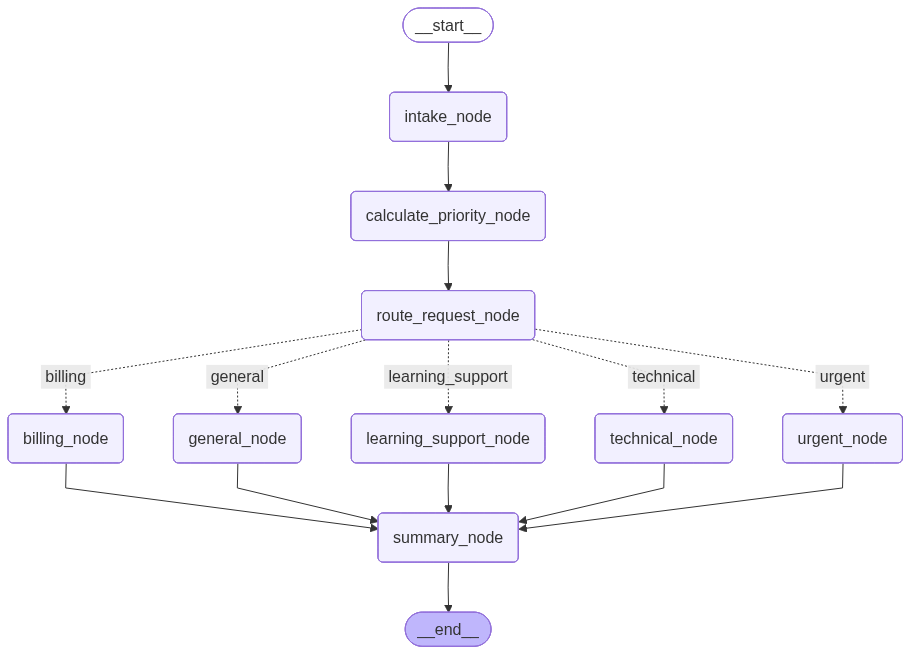

In [6]:
display(Image(workflow.get_graph().draw_mermaid_png()))


In [7]:
input_state: AgentState = {
    "learner_name": "Ada",
    "email": "ada@example.com",
    "category": "technical",
    "message": "My project will not run and the submission is due tonight.",
    "days_until_deadline": 0,
    "is_paid_student": True,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "received",
    "response": "",
    "audit_log": [],
}

result = workflow.invoke(input_state)
print(json.dumps(result, indent=2))


{
  "learner_name": "Ada",
  "email": "ada@example.com",
  "category": "technical",
  "message": "My project will not run and the submission is due tonight.",
  "days_until_deadline": 0,
  "is_paid_student": true,
  "priority_score": 85,
  "priority": "urgent",
  "route": "urgent",
  "assigned_team": "on_call_instructor",
  "status": "escalated",
  "response": "Your request has been marked urgent and escalated for immediate review. A specialist will contact you as soon as possible. Priority: urgent. Assigned team: on_call_instructor.",
  "audit_log": [
    "Received support request from Ada (ada@example.com) in category 'technical'.",
    "Priority calculated: urgent, (85)",
    "Request routed to urgent.",
    "Routed to urgent queue and escalated to on_call_instructor.",
    "Triage summary 'escalated' treated as 'urgent', assigned to 'on_call_instructor' team."
  ]
}
